#  Model Evaluation

### Objectives

- Evaluate clustering performance
- Analyze cluster sizes
- Analyze cluster profiles
- Compare customer segments
- Generate business insights

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score
import joblib

pd.set_option("display.max_columns",None)

In [ ]:
rfm = pd.read_csv("/content/sample_data/clustered_data.csv")
rfm.head()
kmeans = joblib.load("/content/sample_data/kmeans.pkl")
scaler = joblib.load("/content/sample_data/scaler.pkl")

In [ ]:
print(rfm.shape)

rfm.info()

(4338, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   int64  
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
 4   Cluster     4338 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 169.6 KB


In [ ]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

,count
Cluster,
0,2328
1,1046
2,964


In [ ]:
cluster_percentage = round( rfm["Cluster"].value_counts(normalize=True)*100,2)

cluster_percentage

,proportion
Cluster,
0,53.67
1,24.11
2,22.22


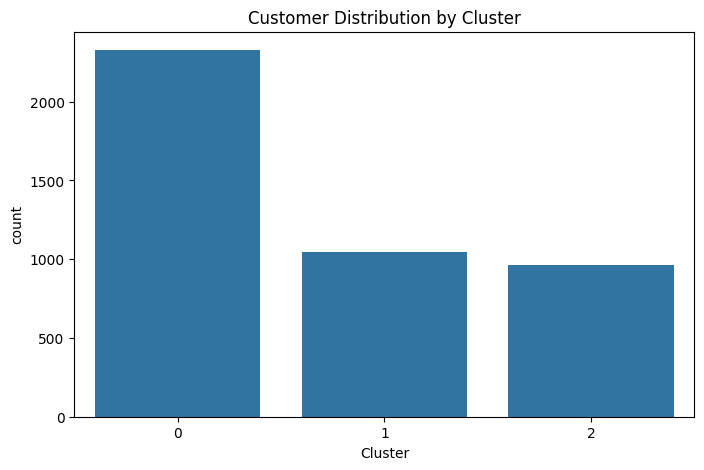

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=rfm,x="Cluster")

plt.title("Customer Distribution by Cluster")

plt.show()

In [ ]:
cluster_profile = (rfm.groupby("Cluster")[ ["Recency","Frequency","Monetary"]].mean().round(2))

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,49.11,2.46,726.14
1,249.64,1.47,498.16
2,26.94,11.69,6924.97


In [ ]:
cluster_revenue = (rfm.groupby("Cluster")["Monetary"].sum().sort_values(ascending=False))

cluster_revenue

,Monetary
Cluster,
2,6675670.830
0,1690461.723
1,521076.341


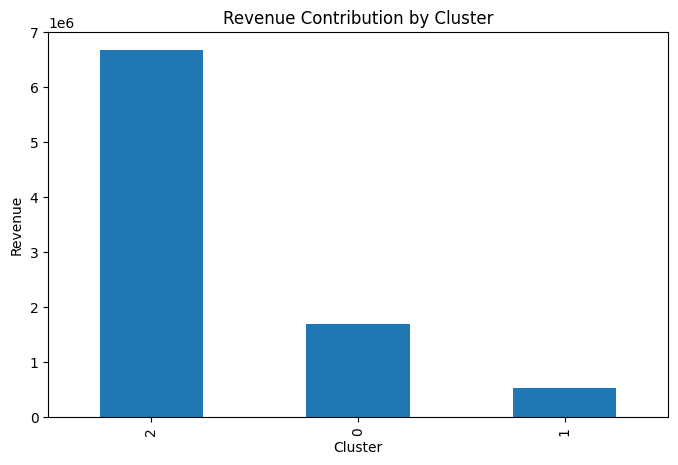

In [ ]:
plt.figure(figsize=(8,5))

cluster_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Cluster")

plt.ylabel("Revenue")

plt.show()

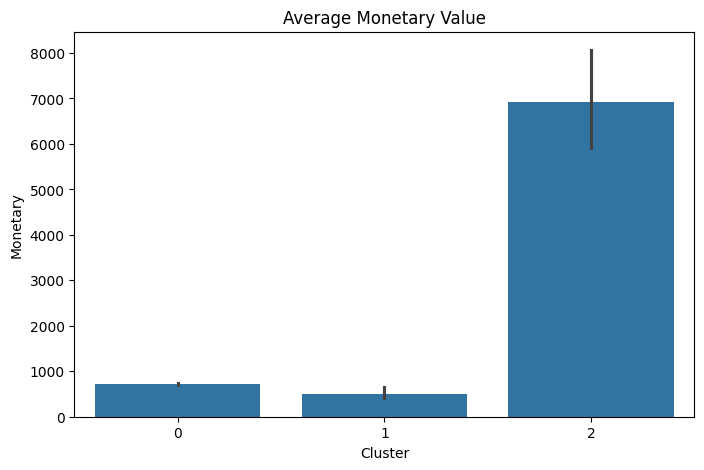

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=rfm,x="Cluster",y="Monetary")
plt.title("Average Monetary Value")

plt.show()

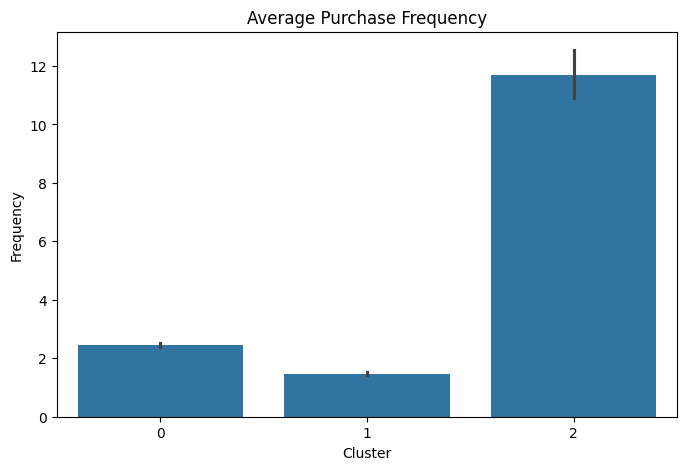

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=rfm,x="Cluster",y="Frequency")
plt.title("Average Purchase Frequency")

plt.show()

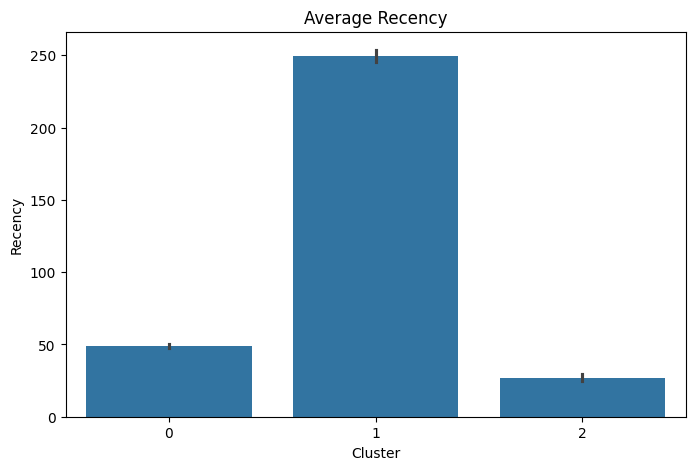

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=rfm,x="Cluster",y="Recency")
plt.title("Average Recency")

plt.show()

In [ ]:
X = rfm[["Recency","Frequency","Monetary"]]

X_scaled = scaler.transform(X)
labels = rfm["Cluster"]

score = silhouette_score(X_scaled,labels)
print("Silhouette Score :",round(score,4))

Silhouette Score : 0.3501


In [ ]:
segment_names = {
    0:"Regular Customers",
    1:"At-Risk Customers",
    2:"VIP Customers"
}
rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,1,At-Risk Customers
1,12347,2,7,4310.00,2,VIP Customers
2,12348,75,4,1797.24,0,Regular Customers
3,12349,19,1,1757.55,0,Regular Customers
4,12350,310,1,334.40,1,At-Risk Customers


In [ ]:
segment_summary = ( rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().round(2))

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,249.64,1.47,498.16
Regular Customers,49.11,2.46,726.14
VIP Customers,26.94,11.69,6924.97


# Business Recommendations

## VIP Customers

- Offer loyalty rewards.
- Provide exclusive discounts.
- Introduce premium memberships.

---

## Regular Customers

- Encourage repeat purchases.
- Recommend related products.
- Offer seasonal promotions.

---

## At-Risk Customers

- Send win-back email campaigns.
- Offer personalized discount coupons.
- Re-engage through SMS and notifications.